Title: PSL_cluster_new.ipynb

Purpose: Make a clustering of large scale weather patterns

Author: Onno Nennecke on 03.06.2025 Modified: 26.03.2026

Input data: 

- PSL Anomaly Data
    - This file lies here: /climca/people/onennecke/model_output/psl_anomaly/not_bc/
- LEE Tables: LEE_dat_14.csv, LEE_dat_7.csv, LEE_dat.csv, LEE_dat_14_selection.csv, LEE_dat_7_selection.csv, LEE_vl.csv
    - This file lies here: '/climca/people/onennecke/model_output/LEE_detection/'

- LEE Tables: LEE_dat_14_fut.csv, LEE_dat_7_fut.csv, LEE_dat_fut.csv, LEE_dat_14_selection_fut.csv, LEE_dat_7_selection_fut.csv, LEE_vl_fut.csv
    - This file lies here: '/climca/people/onennecke/model_output/LEE_detection/'

Output data:

- kmeans scores: psl_kmeans_score_diff_k.csv
    - This file lies here: /home/onennecke/psl_clustering/psl_kmeans_score_diff_k.csv
- Kmeans score Plot: PSL_cluster_elbow_silhouette
    - This file lies here: /home/onennecke/Code/Figures/
- centroids and labels
    - These files lie here: /home/onennecke/psl_clustering/clustering_results_nbc.npz'
    - These files lie here: /home/onennecke/psl_clustering/clustering_results_nbc_2.npz


### Load libraries and functions

In [1]:
# Importing libraries
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl
from matplotlib.ticker import MultipleLocator
from matplotlib.gridspec import GridSpec
from matplotlib.cm import ScalarMappable
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import os
import glob
import time
import cftime
# import datetime
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score


In [2]:
def setup_gridlines(ax, deg = 20, alpha = 0.4):
    gl = ax.gridlines(draw_labels=True, crs=ccrs.PlateCarree(), alpha=alpha)
    gl.top_labels = False
    gl.right_labels = False
    gl.xlabel_style = {'size': 8}
    gl.ylabel_style = {'size': 8}
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    gl.xlocator = MultipleLocator(deg)
    gl.ylocator = MultipleLocator(deg)

In [3]:
path = '/climca/people/onennecke/model_output/psl_anomaly/not_bc'

files = sorted(glob.glob(os.path.join(path, '*.nc')))
ts_datasets = xr.open_mfdataset(files, combine='nested', concat_dim='ESM_run')
ts_datasets['ESM_run'] = ts_datasets['ESM_run'].str.replace('CESM2_LE_LE2', 'CESM2_LE2', regex=False)
ts_datasets

<xarray.Dataset> Size: 3GB
Dimensions:    (ESM_run: 193, time: 1820, lat: 40, lon: 50)
Coordinates:
  * lat        (lat) int64 320B 30 31 32 33 34 35 36 37 ... 63 64 65 66 67 68 69
    crs        (time) int64 15kB dask.array<chunksize=(1820,), meta=np.ndarray>
    gridtype   (time) <U6 44kB dask.array<chunksize=(1820,), meta=np.ndarray>
  * lon        (lon) int64 400B 340 341 342 343 344 345 ... 24 25 26 27 28 29
  * time       (time) object 15kB 2015-01-01 00:00:00 ... 2024-12-31 00:00:00
    ESM        (time, ESM_run) <U13 18MB dask.array<chunksize=(1820, 3), meta=np.ndarray>
    run        (ESM_run, time) <U12 17MB dask.array<chunksize=(3, 1820), meta=np.ndarray>
  * ESM_run    (ESM_run) <U23 18kB 'ACCESS-CM2_r4i1p1f1' ... 'UKESM1-0-LL_r14...
    dayofyear  (time) int64 15kB dask.array<chunksize=(1820,), meta=np.ndarray>
Data variables:
    psl        (ESM_run, time, lat, lon) float32 3GB dask.array<chunksize=(3, 1820, 40, 50), meta=np.ndarray>

## Select only relevant timesteps for the clustering!!

### Select relevant timesteps

In [4]:
# Read the LEE data
LEE_dat = pd.read_csv('/climca/people/onennecke/model_output/LEE_detection/LEE_dat.csv')

LEE_dat_7_all = pd.read_csv('/climca/people/onennecke/model_output/LEE_detection/LEE_dat_7.csv')
LEE_7 = pd.read_csv('/climca/people/onennecke/model_output/LEE_detection/LEE_dat_7_selection.csv')

LEE_dat_14_all = pd.read_csv('/climca/people/onennecke/model_output/LEE_detection/LEE_dat_14.csv')
LEE_14 = pd.read_csv('/climca/people/onennecke/model_output/LEE_detection/LEE_dat_14_selection.csv')

LEE_vl = pd.read_csv('/climca/people/onennecke/model_output/LEE_detection/LEE_vl.csv')

In [5]:
# Remove all SMARD and ERA5_wwd data from the LEE_dat DataFrame
LEE_dat = LEE_dat[(LEE_dat['ESM'] != 'SMARD') & (LEE_dat['ESM'] != 'ERA5_wwd')]
LEE_7 = LEE_7[(LEE_7['ESM'] != 'SMARD') & (LEE_7['ESM'] != 'ERA5_wwd')]
LEE_14 = LEE_14[(LEE_14['ESM'] != 'SMARD') & (LEE_14['ESM'] != 'ERA5_wwd')]
LEE_vl = LEE_vl[(LEE_vl['ESM'] != 'SMARD') & (LEE_vl['ESM'] != 'ERA5_wwd')]

# Rename ESM_run for ERA5_hist_week to ERA5_hist
LEE_dat['ESM_run'] = LEE_dat['ESM_run'].replace({'ERA5_hist_week': 'ERA5_hist'})
LEE_7['ESM_run'] = LEE_7['ESM_run'].replace({'ERA5_hist_week': 'ERA5_hist'})
LEE_14['ESM_run'] = LEE_14['ESM_run'].replace({'ERA5_hist_week': 'ERA5_hist'})
LEE_vl['ESM_run'] = LEE_vl['ESM_run'].replace({'ERA5_hist_week': 'ERA5_hist'})

# Kick every date in April
LEE_dat = LEE_dat[LEE_dat['date_start'].str[5:7] != '04']
LEE_7 = LEE_7[LEE_7['date_start'].str[5:7] != '04']
LEE_14 = LEE_14[LEE_14['date_start'].str[5:7] != '04']
LEE_vl = LEE_vl[LEE_vl['date_start'].str[5:7] != '04']


In [6]:
LEE_dat[LEE_dat['ESM_run'] == 'ACCESS-CM2_r4i1p1f1']

,date_start,date_end,date_peak,index_start,index_end,index_peak,duration,RL_max,RL_mean,RL_var,RL_cumulative,event,ESM,ESM_run,year,doy
217,2015-01-06,2015-01-06,2015-01-06,5,5,5,1,1347.001409,1347.001409,0.0,1347.001409,218,ACCESS-CM2,ACCESS-CM2_r4i1p1f1,2015,6
218,2015-02-02,2015-02-02,2015-02-02,32,32,32,1,1387.128827,1387.128827,0.0,1387.128827,219,ACCESS-CM2,ACCESS-CM2_r4i1p1f1,2015,33
219,2015-02-03,2015-02-03,2015-02-03,33,33,33,1,1428.428099,1428.428099,0.0,1428.428099,220,ACCESS-CM2,ACCESS-CM2_r4i1p1f1,2015,34
220,2015-02-05,2015-02-05,2015-02-05,35,35,35,1,1367.866815,1367.866815,0.0,1367.866815,221,ACCESS-CM2,ACCESS-CM2_r4i1p1f1,2015,36
221,2015-02-18,2015-02-18,2015-02-18,48,48,48,1,1348.094643,1348.094643,0.0,1348.094643,222,ACCESS-CM2,ACCESS-CM2_r4i1p1f1,2015,49
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
410,2024-01-09,2024-01-09,2024-01-09,3293,3293,3293,1,1421.257277,1421.257277,0.0,1421.257277,411,ACCESS-CM2,ACCESS-CM2_r4i1p1f1,2024,9
411,2024-02-01,2024-02-01,2024-02-01,3316,3316,3316,1,1349.966223,1349.966223,0.0,1349.966223,412,ACCESS-CM2,ACCESS-CM2_r4i1p1f1,2024,32
412,2024-11-07,2024-11-07,2024-11-07,3595,3595,3595,1,1382.736068,1382.736068,0.0,1382.736068,413,ACCESS-CM2,ACCESS-CM2_r4i1p1f1,2024,311
413,2024-12-06,2024-12-06,2024-12-06,3624,3624,3624,1,1346.275347,1346.275347,0.0,1346.275347,414,ACCESS-CM2,ACCESS-CM2_r4i1p1f1,2024,340


In [7]:
ts_datasets_filtered = ts_datasets.copy()

In [8]:
date_map = (
    LEE_dat.groupby("ESM_run")["date_start"]
    .apply(list)
    .to_dict()
)
ts_datasets_filtered = ts_datasets.copy()
mask = xr.zeros_like(ts_datasets_filtered.time, dtype=bool)

for esm, dates in date_map.items():
    dates_formatted = [
        cftime.DatetimeNoLeap(int(date[:4]), int(date[5:7]), int(date[8:10]))
        for date in dates
    ]

    mask = mask | (
        (ts_datasets_filtered.ESM_run == esm) &
        (ts_datasets_filtered.time.isin(dates_formatted))
    )

ts_datasets_filtered = ts_datasets_filtered.where(mask, drop=True)

In [10]:
ts_datasets_filtered

<xarray.Dataset> Size: 2GB
Dimensions:    (ESM_run: 193, time: 1523, lat: 40, lon: 50)
Coordinates:
  * lat        (lat) int64 320B 30 31 32 33 34 35 36 37 ... 63 64 65 66 67 68 69
    crs        (time) int64 12kB dask.array<chunksize=(1523,), meta=np.ndarray>
    gridtype   (time) <U6 37kB dask.array<chunksize=(1523,), meta=np.ndarray>
  * lon        (lon) int64 400B 340 341 342 343 344 345 ... 24 25 26 27 28 29
  * time       (time) object 12kB 2015-01-01 00:00:00 ... 2024-12-31 00:00:00
    ESM        (time, ESM_run) <U13 15MB dask.array<chunksize=(1523, 3), meta=np.ndarray>
    run        (ESM_run, time) <U12 14MB dask.array<chunksize=(3, 1523), meta=np.ndarray>
  * ESM_run    (ESM_run) <U23 18kB 'ACCESS-CM2_r4i1p1f1' ... 'UKESM1-0-LL_r14...
    dayofyear  (time) int64 12kB dask.array<chunksize=(1523,), meta=np.ndarray>
Data variables:
    psl        (ESM_run, time, lat, lon) float32 2GB dask.array<chunksize=(3, 1523, 40, 50), meta=np.ndarray>

# Clustering

In [11]:
# Determine the number of clusters
k = 5

In [12]:
# 1. Load PSL data
ts_datasets_filtered
psl = ts_datasets_filtered['psl']
# psl

# lats = psl['lat'].values                        # shape: (n_lat,)
# coslat = np.cos(np.deg2rad(lats))               # area ∝ cos(lat)
# weights_1d = np.sqrt(coslat)                    # √area weighting

# n_lat = psl.sizes['lat']
# n_lon = psl.sizes['lon']

# # this makes an array of length n_lat * n_lon
# weights_2d = np.repeat(weights_1d, n_lon)       # shape: (n_lat*n_lon,)

In [ ]:
# # 2. Flatten each time‐slice
# n_times = psl.sizes['time']
# n_lat = psl.sizes['lat']
# n_lon = psl.sizes['lon']
# n_ESM = psl.sizes['ESM_run']
# print(n_times)
# print(n_lat)
# print(n_lon)
# print(n_ESM)
# arr_flat = psl.values.reshape(n_times * n_ESM, n_lat * n_lon)

# # area‐weight every feature (column) by sqrt(cos(lat))
# X_weighted = arr_flat * weights_2d[np.newaxis, :]

1523
40
50
193


In [13]:
psl_stacked = psl.stack(sample=("time", "ESM_run"))
# remove samples that are fully NaN
psl_stacked = psl_stacked.dropna(dim="sample", how="all")
psl_2d = psl_stacked.stack(space=("lat", "lon"))
X = psl_2d.values

weights = np.repeat(
    np.sqrt(np.cos(np.deg2rad(psl.lat.values))),
    psl.sizes["lon"]
)
X_weighted = X * weights[np.newaxis, :] 

In [14]:
np.shape(weights[np.newaxis, :])
# np.shape(weights)
np.shape(X)
np.shape(X_weighted)

(35217, 2000)

#### Calculate PCA

In [15]:
# PCA to reduce dimensionality
pca = PCA(n_components=0.90, svd_solver='full')  # keep 90% variance
X_pca = pca.fit_transform(X_weighted)  # shape: (n_times, n_eofs)
print(pca.n_components_)
# X_pca

7


In [16]:
print("Explained variance ratio per component:")
print(pca.explained_variance_ratio_)

print("Cumulative explained variance:")
print(pca.explained_variance_ratio_.cumsum())

Explained variance ratio per component:
[0.42340541 0.16913314 0.13156233 0.08248987 0.05609696 0.03637107
 0.02187663]
Cumulative explained variance:
[0.42340541 0.59253855 0.72410088 0.80659075 0.86268771 0.89905878
 0.92093541]


In [17]:
print(X_weighted.shape)  # original
print(X_pca.shape)       # reduced

(35217, 2000)
(35217, 7)


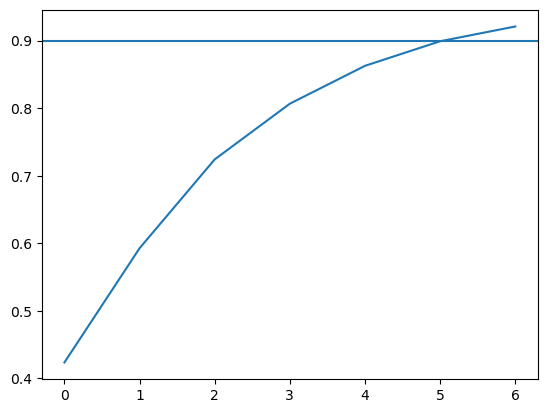

In [18]:
# import matplotlib.pyplot as plt
plt.plot(pca.explained_variance_ratio_.cumsum())
plt.axhline(0.9)
plt.show()

##### Determine optimal k

In [117]:
# !!! Takes a bit if you run it on the full dataset !!!

# ----------------------------------------------------------------------
# 1) Elbow plot + Silhouette‐score vs. k
# ----------------------------------------------------------------------

# Choose which k‐values to test:
k_range = range(2, 11)  # e.g. test k = 2, 3, …, 10

inertias = []
silhouettes = []

for k_test in k_range:
    print(f"Testing k = {k_test} ...")
    km = KMeans(n_clusters=k_test, n_init=20, random_state=1)
    labels_k = km.fit_predict(X_pca)      # cluster in EOF‐space
    inertias.append(km.inertia_)          # sum of squared distances to centroids

    # Silhouette: only valid if k_test < n_samples
    silh = silhouette_score(X_pca, labels_k)
    silhouettes.append(silh)


Testing k = 2 ...
Testing k = 3 ...
Testing k = 4 ...
Testing k = 5 ...
Testing k = 6 ...
Testing k = 7 ...
Testing k = 8 ...
Testing k = 9 ...
Testing k = 10 ...


In [118]:
# Save k_range, inertias and silhouettes in a dataframe
df_results = pd.DataFrame({
    'k': list(k_range),
    'inertia': inertias,
    'silhouette': silhouettes
})
# Save the results to a CSV file
df_results.to_csv('/home/onennecke/psl_clustering/psl_kmeans_high_RL_score_diff_k.csv', index=False)

In [119]:
df_results

,k,inertia,silhouette
0,2,2.984591e+13,0.259379
1,3,2.618856e+13,0.172837
2,4,2.340016e+13,0.175176
3,5,2.172571e+13,0.165775
4,6,2.040673e+13,0.149954
5,7,1.941392e+13,0.143049
6,8,1.849072e+13,0.141228
7,9,1.781201e+13,0.137370
8,10,1.724110e+13,0.131575


In [19]:
# Read the results from the CSV file
df_results = pd.read_csv('/home/onennecke/psl_clustering/psl_kmeans_high_RL_score_diff_k.csv')

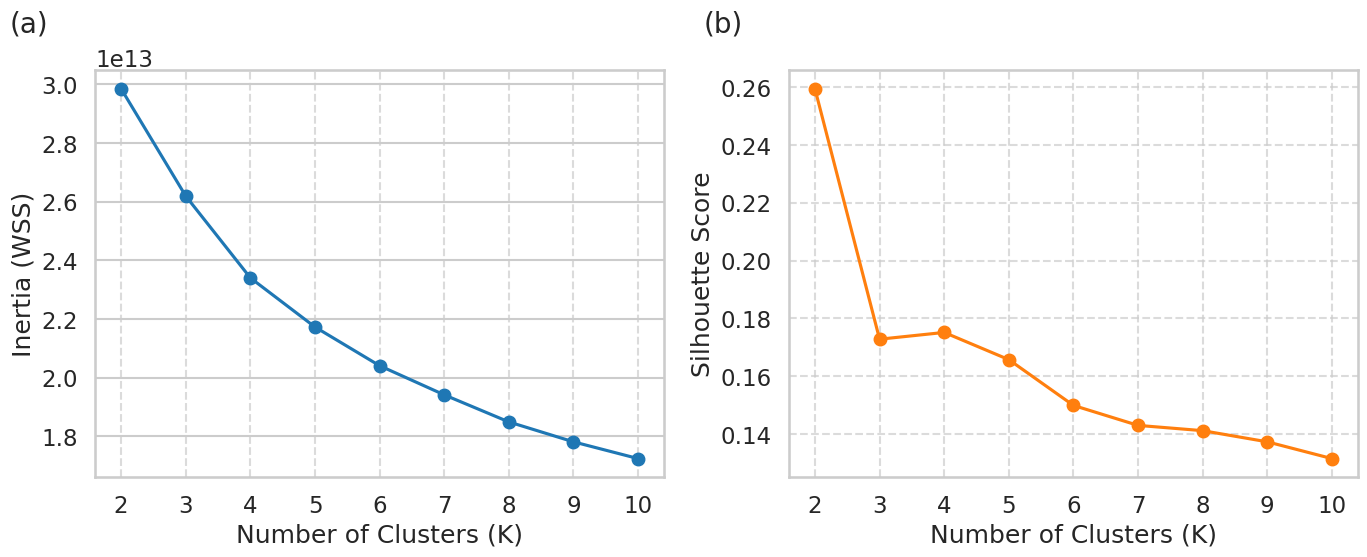

In [20]:
# keep text sizing consistent
mpl.rcParams.update({
    'font.size': 16,
    'axes.titlesize': 18,
    'axes.labelsize': 16,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 16,
    'figure.titlesize': 18,
})


# ensure K is sorted and in a list
ks = sorted(df_results['k'].unique())

sns.set_style("whitegrid")
sns.set_context("talk")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), sharex=True)

# a) Elbow plot
ax1.plot(df_results['k'], df_results['inertia'], marker='o', linestyle='-', color='C0')
ax1.set_xlabel("Number of Clusters (K)")
ax1.set_ylabel("Inertia (WSS)")
# ax1.set_ylim(0, df_results['inertia'].max() * 1.1)  # extend y-axis a bit
ax1.set_xticks(ks)                                # label every K
ax1.grid(True, axis='x', linestyle='--', alpha=0.7)  # vertical grid lines
ax2.grid(True, axis='y', linestyle='--', alpha=0.7)  # horizontal grid lines
ax1.text(-0.15, 1.15, "(a)", transform=ax1.transAxes, fontsize = 20, va='top')

# b) Silhouette score
ax2.plot(df_results['k'], df_results['silhouette'], marker='o', linestyle='-', color='C1')
ax2.set_xlabel("Number of Clusters (K)")
ax2.set_ylabel("Silhouette Score")
# ax2.set_ylim(0, df_results['silhouette'].max() * 1.1)  # extend y-axis a bit
ax2.set_xticks(ks)                                # label every K
ax2.grid(True, axis='x', linestyle='--', alpha=0.7)  # vertical grid lines
ax2.grid(True, axis='y', linestyle='--', alpha=0.7)  # horizontal grid lines
ax2.text(-0.15, 1.15, "(b)", transform=ax2.transAxes, fontsize = 20, va='top')

plt.tight_layout()
# Save the figure
# plt.savefig('/home/onennecke/Code/Figures/PSL_cluster_elbow_silhouette.png', dpi=300, bbox_inches='tight')
plt.show()

#### Calculate KMeans with optimal k

In [21]:
k_opt = 4
kmeans = KMeans(n_clusters=k_opt, n_init=20, random_state=0)
kmeans_2 = KMeans(n_clusters=k_opt, n_init=20, random_state=0)

In [22]:
# 3. Run KMeans 
kmeans.fit(X_pca)  # fit in EOF space
# 4. Extract labels & centroids (in EOF space)
labels = kmeans.labels_            # array length = n_times
centroids_pca = kmeans.cluster_centers_  # shape (k, n_eofs)
# 4.1 Convert centroids back to original space
centroids = pca.inverse_transform(centroids_pca)  # shape (k, n_lat * n_lon)

# 5. Reshape centroids to lat/lon grid
centroids_reshaped = centroids.reshape(k_opt, psl.sizes['lat'], psl.sizes['lon'])  # shape (k, n_lat, n_lon)

In [125]:
centroids_pca

array([[ 27024.49250501,   1679.03984707,   -501.66442703,
         -1566.31910109,    294.87325834,    313.12313099,
           154.03262945],
       [-33889.17950631,   -218.28749321,   -177.87160505,
         -1878.97678312,    828.74805766,    705.33938855,
           417.6413366 ],
       [ -3688.10778655,  15360.70212569,    538.58731287,
           844.08216345,    389.4266731 ,   -227.09854327,
          -166.00618424],
       [   872.29082958, -13265.22378803,    199.14612623,
          2210.26649444,  -1176.43158058,   -632.52753413,
          -319.93723091]])

In [126]:
centroids

array([[-235.75582071, -234.95907892, -233.62062188, ...,  503.67808932,
         490.7196106 ,  476.97256393],
       [ -79.68031587,  -88.88150265,  -99.29820569, ...,  292.61236001,
         288.98591708,  285.78585068],
       [-427.43200807, -431.3036629 , -434.87688448, ...,  644.91643759,
         628.58248152,  612.13536007],
       [  68.20600589,   62.01610367,   54.91640228, ...,  492.47649739,
         496.06014487,  499.00518435]])

In [127]:
centroids_reshaped

array([[[-2.35755821e+02, -2.34959079e+02, -2.33620622e+02, ...,
          3.87948063e+00,  3.05794203e+00,  2.24816905e+00],
        [-2.42264478e+02, -2.40996912e+02, -2.38913053e+02, ...,
          5.14567947e+00,  2.82225206e+00,  7.37010871e-01],
        [-2.44275111e+02, -2.42437219e+02, -2.39726461e+02, ...,
          7.99339638e+00,  3.90419430e+00,  1.07943227e-01],
        ...,
        [ 9.44870861e+01,  1.31334667e+02,  1.68697616e+02, ...,
          6.82931556e+02,  6.63360098e+02,  6.41715326e+02],
        [ 9.60894851e+00,  4.39145850e+01,  7.96926102e+01, ...,
          5.91349492e+02,  5.75178084e+02,  5.57736900e+02],
        [-5.74419220e+01, -2.99342869e+01,  5.10300266e-01, ...,
          5.03678089e+02,  4.90719611e+02,  4.76972564e+02]],

       [[-7.96803159e+01, -8.88815026e+01, -9.92982057e+01, ...,
         -1.58878708e+02, -1.37521018e+02, -1.18241679e+02],
        [-9.80548200e+01, -1.08320545e+02, -1.19823459e+02, ...,
         -1.60319743e+02, -1.33828975e

In [128]:
# Save centroids and labels to a folder
output_dir = '/home/onennecke/psl_clustering/clustering_results_nbc.npz'
np.savez(output_dir, centroids_reshaped=centroids_reshaped, labels=labels)



In [129]:
data = np.load('/home/onennecke/psl_clustering/clustering_results_nbc.npz')
labels = data['labels']
centroids_reshaped = data['centroids_reshaped']

In [130]:
score = silhouette_score(X_pca, labels)
print("Silhouette Score:", score)

Silhouette Score: 0.17504067374311175


In [131]:
print(labels.shape)
print(centroids_reshaped.shape)

(35217,)
(4, 40, 50)


In [132]:
# Fit in EOF‐space and get labels
labels_2 = kmeans_2.fit_predict(X_pca)      # length = n_samples = n_times*n_ESM

# Now, arr_flat has shape (n_samples, n_lat*n_lon).  Each row = one (time, ESM) flattened.
# We want to compute, for i = 0..k_opt-1:
#   mean_flat_i = mean over all samples whose label == i
#   then reshape mean_flat_i → (n_lat, n_lon)

cluster_means = np.zeros((k_opt, n_lat, n_lon))

for i in range(k_opt):
    idx_i = np.where(labels_2 == i)[0]             # all sample‐indices in cluster i
    mean_flat_i = np.mean(arr_flat[idx_i, :], axis=0)  
    cluster_means[i, :, :] = mean_flat_i.reshape(n_lat, n_lon)

# Now cluster_means[i] is the composite PSL field (still in whatever units arr_flat had).
# If arr_flat was “raw PSL,” then these are raw composites.  If arr_flat was “anomalies,”
# add back your climatology if you want absolute values.  But the plotting procedure is the same.


In [133]:
# Save centroids and labels to a folder
output_dir = '/home/onennecke/psl_clustering/clustering_results_nbc_2.npz'
np.savez(output_dir, cluster_means=cluster_means, labels=labels_2)

data = np.load('/home/onennecke/psl_clustering/clustering_results_nbc_2.npz')
labels_3 = data['labels']
cluster_means_3 = data['cluster_means']

In [134]:
score = silhouette_score(X_pca, labels_2)
print("Silhouette Score:", score)

Silhouette Score: 0.17504067374311175


In [135]:
print(labels_2.shape)
print(cluster_means.shape)

(35217,)
(4, 40, 50)


In [136]:
# Check if labels_2 and labels are the same
if np.array_equal(labels, labels_2):
    print("Labels are the same")
else:
    print("Labels are different")

Labels are the same


In [137]:
centroids_reshaped[1, :, :]

array([[ -79.68031587,  -88.88150265,  -99.29820569, ..., -158.87870804,
        -137.52101803, -118.24167897],
       [ -98.05481999, -108.3205446 , -119.8234592 , ..., -160.31974334,
        -133.82897458, -110.52399872],
       [-119.1863085 , -130.32855288, -142.64580009, ..., -166.68949995,
        -134.86369606, -106.42475243],
       ...,
       [ 548.0542045 ,  551.97480589,  555.31046135, ...,  225.75517518,
         223.14498592,  221.52708997],
       [ 548.25945765,  553.74713642,  558.75399972, ...,  262.10663768,
         258.84540424,  256.13819517],
       [ 540.27936368,  547.20095283,  554.04317858, ...,  292.61236001,
         288.98591708,  285.78585068]])

In [1]:
cluster_means[0, :, :]

NameError: name 'cluster_means' is not defined

/tmp/ipykernel_3317053/3672292719.py:48: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.03, 1, 1])  # leave bottom ~3% of figure for cbar


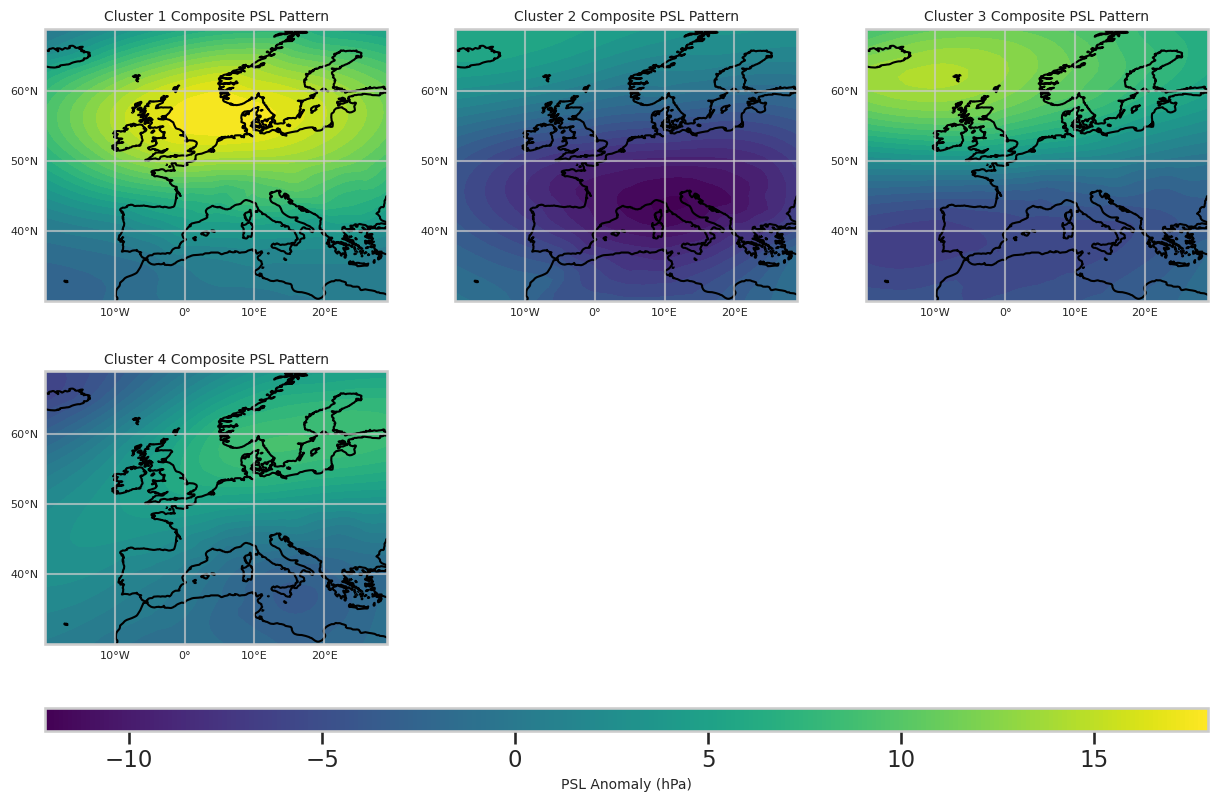

In [23]:
# 1) Compute the global vmin/vmax over all clusters (in hPa)
vmin = np.nanmin(centroids_reshaped / 100.0)
vmax = np.nanmax(centroids_reshaped / 100.0)

# 2) Decide on subplot grid
ncols = 3
nrows = int(np.ceil(k_opt / ncols))

# 3) Create figure + GridSpec (last row for cbar)
fig = plt.figure(figsize=(5 * ncols, 4 * (nrows + 0.3)))
gs = GridSpec(nrows + 1, ncols,
              height_ratios=[1] * nrows + [0.08],
              hspace=0.3, wspace=0.2)

lons = ((ts_datasets['lon'].values + 180) % 360) - 180
lats = ts_datasets['lat'].values

for i in range(k_opt):
    row = i // ncols
    col = i % ncols
    ax = fig.add_subplot(gs[row, col], projection=ccrs.PlateCarree())

    # Plot with fixed vmin/vmax
    cf = ax.contourf(lons, lats,(centroids_reshaped[i, :, :] / 100.0),levels=20,vmin=vmin,vmax=vmax,transform=ccrs.PlateCarree(), cmap='viridis')
    cmap_used = cf.cmap  # capture the colormap for later

    ax.coastlines()
    setup_gridlines(ax, deg=10, alpha=0.7)
    ax.set_title(f"Cluster {i + 1} Composite PSL Pattern", fontsize=10)

# 5) Hide any “extra” empty axes if k_opt < nrows*ncols
for j in range(k_opt, nrows * ncols):
    row = j // ncols
    col = j % ncols
    fig.add_subplot(gs[row, col]).axis("off")

# 6) Create a ScalarMappable just for the colorbar, using the same colormap/norm
norm = plt.Normalize(vmin=vmin, vmax=vmax)
sm = ScalarMappable(norm=norm, cmap=cmap_used)
sm.set_array([])  # no actual data needed, just for the colorbar

# 7) Place the horizontal colorbar in the final GridSpec row, spanning all columns
cax = fig.add_subplot(gs[nrows, :])
cbar = fig.colorbar(sm, cax=cax, orientation="horizontal", pad=0.02)
cbar.set_label('PSL Anomaly (hPa)', fontsize=10)

# 8) Tweak layout so maps and cbar don’t overlap
plt.tight_layout(rect=[0, 0.03, 1, 1])  # leave bottom ~3% of figure for cbar
plt.show()


### Check something probably delete

##### Look how the clusters are seasonaly distributed

In [39]:
ts_datasets_filtered.sizes['ESM_run']
len(ts_datasets_filtered['ESM'])

1523

In [43]:
print(len(ts_datasets_filtered['ESM'].values))
print(len(ts_datasets_filtered['ESM'].values[0]))

1523
193


In [44]:
1523 * 193

293939

In [51]:
ts_datasets_filtered

<xarray.Dataset> Size: 2GB
Dimensions:    (ESM_run: 193, time: 1523, lat: 40, lon: 50)
Coordinates:
  * lat        (lat) int64 320B 30 31 32 33 34 35 36 37 ... 63 64 65 66 67 68 69
    crs        (time) int64 12kB dask.array<chunksize=(1523,), meta=np.ndarray>
    gridtype   (time) <U6 37kB dask.array<chunksize=(1523,), meta=np.ndarray>
  * lon        (lon) int64 400B 340 341 342 343 344 345 ... 24 25 26 27 28 29
  * time       (time) object 12kB 2015-01-01 00:00:00 ... 2024-12-31 00:00:00
    ESM        (time, ESM_run) <U13 15MB dask.array<chunksize=(1523, 3), meta=np.ndarray>
    run        (ESM_run, time) <U12 14MB dask.array<chunksize=(3, 1523), meta=np.ndarray>
  * ESM_run    (ESM_run) <U23 18kB 'ACCESS-CM2_r4i1p1f1' ... 'UKESM1-0-LL_r14...
    dayofyear  (time) int64 12kB dask.array<chunksize=(1523,), meta=np.ndarray>
Data variables:
    psl        (ESM_run, time, lat, lon) float32 2GB dask.array<chunksize=(3, 1523, 40, 50), meta=np.ndarray>

In [54]:
psl_stacked = psl.stack(sample=("time", "ESM_run"))
psl_stacked = psl_stacked.dropna(dim="sample", how="all")

# Extract coordinates aligned with labels
sample_index = psl_stacked.sample.to_index()

df = pd.DataFrame({
    "time": sample_index.get_level_values("time"),
    "ESM_run": sample_index.get_level_values("ESM_run"),
    "cluster": labels
})

# Optional: add ESM (you already have it in dataset)
# Need to align it properly:
esm_lookup = ts_datasets_filtered["ESM"].to_series()

df["ESM"] = [
    esm_lookup.loc[(t, esm_run)]
    for t, esm_run in zip(df["time"], df["ESM_run"])
]

In [60]:
df['time'][0].month

1

In [56]:
# Calculate how often each cluster occurs and the occurence probability
cluster_counts = df['cluster'].value_counts().sort_index()
total_counts = len(df)
cluster_probabilities = cluster_counts / total_counts
print("Cluster Occurrences:\n", cluster_counts)
print("\nCluster Occurrence Probabilities:\n", cluster_probabilities)

Cluster Occurrences:
 cluster
0     9887
1     7284
2     7842
3    10204
Name: count, dtype: int64

Cluster Occurrence Probabilities:
 cluster
0    0.280745
1    0.206832
2    0.222677
3    0.289746
Name: count, dtype: float64


--- 

In [62]:
# ────────────── 3) Map each date → its meteorological season ──────────────

def month_to_season(m):
    # Meteorological seasons in the northern hemisphere:
    if m in (12, 1, 2):
        return "DJF"
    elif m in (3, 4, 5):
        return "MAM"
    elif m in (6, 7, 8):
        return "JJA"
    else:  # 9,10,11
        return "SON"

# Extract month from each timestamp, then map to season:
df["month"]  = df["time"].apply(lambda x: x.month)
df["season"] = df["month"].map(month_to_season)
# df


In [64]:
# ────────────── 4) Count how many samples of each cluster fall in each season ──────────────

# This gives you a table with index = cluster ID, columns = season, and counts = number of samples.
monthly_counts = (
    df
    .groupby(["cluster", "month"])
    .size()
    .unstack(fill_value=0)
)  
# e.g. monthly_counts.loc[2, "JJA"] is “how many cluster–2 days fall in summer (JJA).”

# If you want fractions instead of raw counts, you can do:
monthly_frac = monthly_counts.div(monthly_counts.sum(axis=1), axis=0)
# Now each row sums to 1, so monthly_frac.loc[i, s] is the fraction of cluster i’s samples in season s.


In [65]:
monthly_frac
# Calculate the sum per month
monthly_sum = monthly_counts.sum(axis=0)
monthly_sum
# Oktober passt
# November passt
# Dezember passt
# Januar passt
# Februar passt


month
1     11428
2      5411
3       675
10      257
11     5946
12    11500
dtype: int64

In [80]:
df[0:20]

,time,ESM_run,cluster,ESM,month,season
0,2015-01-01 00:00:00,CESM2_LE2-1071_004,1,CESM2_LE,1,DJF
1,2015-01-01 00:00:00,CESM2_LE2-1171_009,3,CESM2_LE,1,DJF
2,2015-01-01 00:00:00,CESM2_LE2-1231_002,0,CESM2_LE,1,DJF
3,2015-01-01 00:00:00,CESM2_LE2-1231_003,3,CESM2_LE,1,DJF
4,2015-01-01 00:00:00,CESM2_LE2-1231_011,0,CESM2_LE,1,DJF
5,2015-01-01 00:00:00,CESM2_LE2-1231_013,2,CESM2_LE,1,DJF
6,2015-01-01 00:00:00,CESM2_LE2-1231_020,2,CESM2_LE,1,DJF
7,2015-01-01 00:00:00,CESM2_LE2-1251_002,1,CESM2_LE,1,DJF
8,2015-01-01 00:00:00,CESM2_LE2-1251_011,1,CESM2_LE,1,DJF
9,2015-01-01 00:00:00,CESM2_LE2-1251_012,2,CESM2_LE,1,DJF


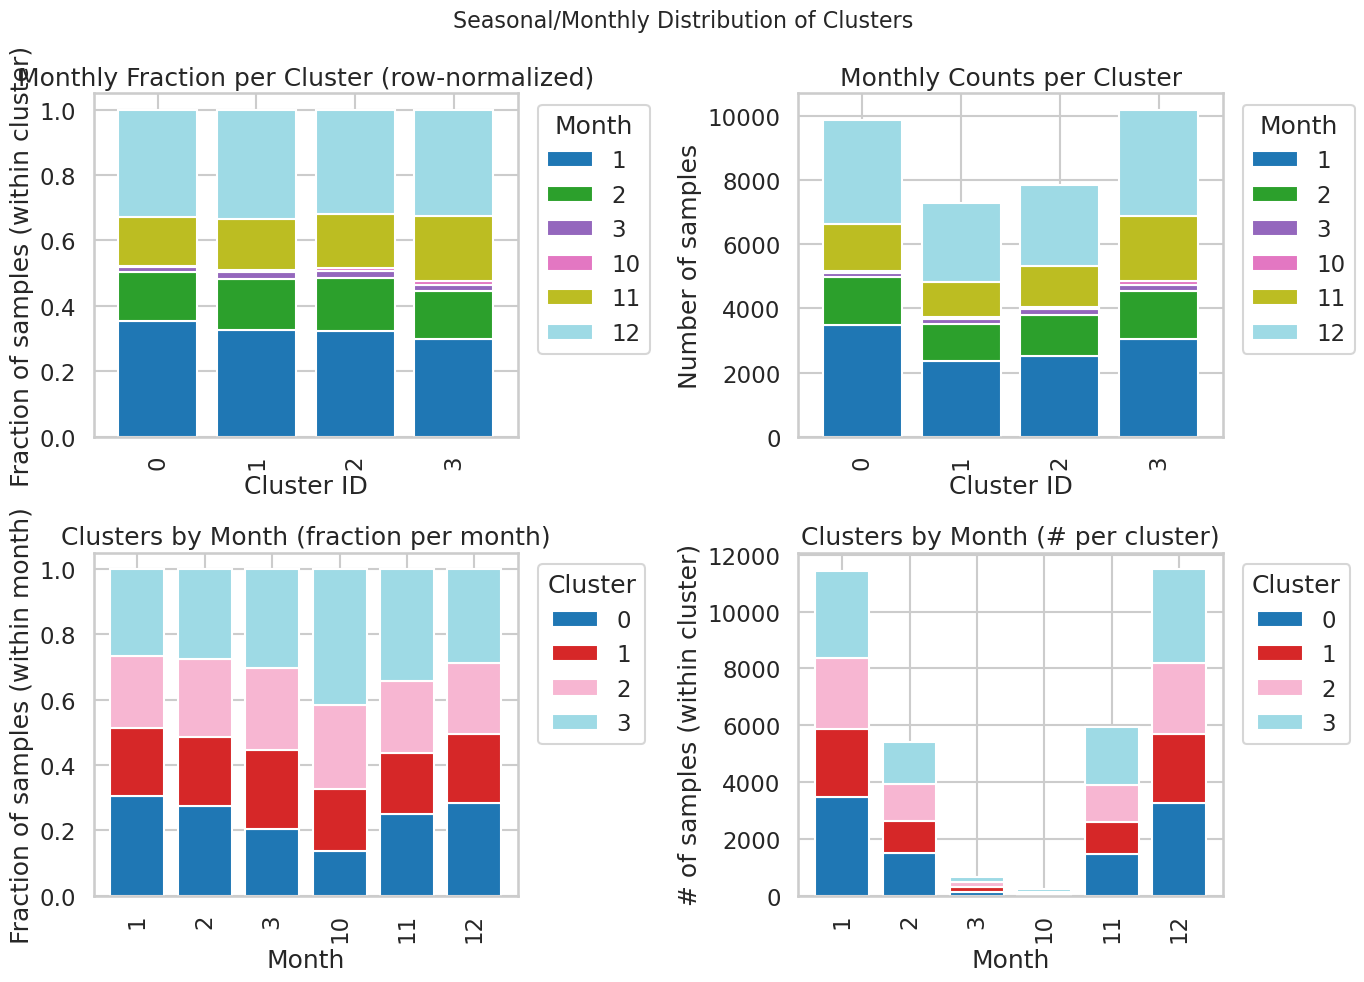

In [66]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 10))
axes = axes.flatten()

# 1) Top‐Left: monthly_frac (clusters on x‐axis, months stacked)
monthly_frac.plot(
    kind="bar",
    stacked=True,
    ax=axes[0],
    colormap="tab20",
    width=0.8
)
axes[0].set_xlabel("Cluster ID")
axes[0].set_ylabel("Fraction of samples (within cluster)")
axes[0].set_title("Monthly Fraction per Cluster (row‐normalized)")
axes[0].legend(title="Month", bbox_to_anchor=(1.02, 1), loc="upper left")

# 2) Top‐Right: monthly_counts (clusters on x‐axis, months stacked)
monthly_counts.plot(
    kind="bar",
    stacked=True,
    ax=axes[1],
    colormap="tab20",
    width=0.8
)
axes[1].set_xlabel("Cluster ID")
axes[1].set_ylabel("Number of samples")
axes[1].set_title("Monthly Counts per Cluster")
axes[1].legend(title="Month", bbox_to_anchor=(1.02, 1), loc="upper left")

# 3) Bottom‐Right: monthly_frac_within_month.T (months on x‐axis, clusters stacked; fraction within month)
monthly_frac_within_month = monthly_counts.div(monthly_counts.sum(axis=0), axis=1)

monthly_frac_within_month.T.plot(
    kind="bar",
    stacked=True,
    ax=axes[2],
    colormap="tab20",
    width=0.8
)
axes[2].set_xlabel("Month")
axes[2].set_ylabel("Fraction of samples (within month)")
axes[2].set_title("Clusters by Month (fraction per month)")
axes[2].legend(title="Cluster", bbox_to_anchor=(1.02, 1), loc="upper left")

# 3) Bottom‐Left: monthly_counts.T (months on x‐axis, clusters stacked; fraction within cluster)
monthly_counts.T.plot(
    kind="bar",
    stacked=True,
    ax=axes[3],
    colormap="tab20",
    width=0.8
)
axes[3].set_xlabel("Month")
axes[3].set_ylabel("# of samples (within cluster)")
axes[3].set_title("Clusters by Month (# per cluster)")
axes[3].legend(title="Cluster", bbox_to_anchor=(1.02, 1), loc="upper left")



# ────────────── D) Adjust layout ──────────────

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.suptitle("Seasonal/Monthly Distribution of Clusters", fontsize=16, y=0.99)
plt.show()

----

### Look at distribution for each ESM

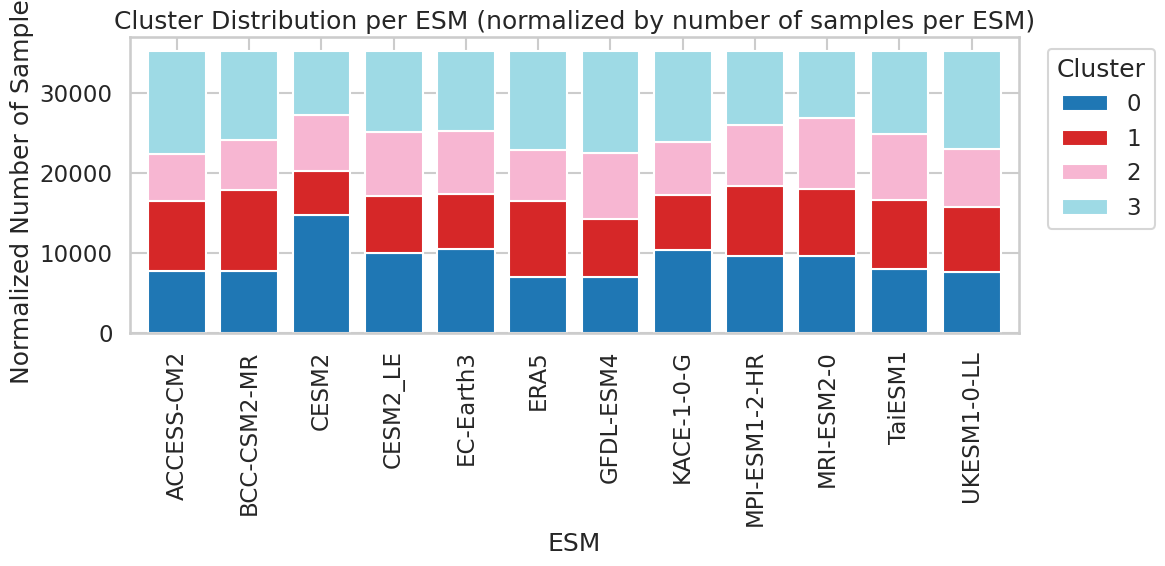

In [67]:
# Make one plot for all ESMs each represented by a stacked barplot normalize by number of samples per ESM
# Calculate the number of samples per ESM
samples_per_esm = df['ESM'].value_counts()
samples_per_esm = samples_per_esm / samples_per_esm.sum()

# Group by ESM and cluster, then count occurrences
esm_cluster_counts = df.groupby(['ESM', 'cluster']).size().unstack(fill_value=0)
esm_cluster_counts = esm_cluster_counts.div(samples_per_esm, axis=0)
esm_cluster_counts.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6),
    colormap="tab20",
    width=0.8
)
plt.xlabel("ESM")
plt.ylabel("Normalized Number of Samples")
plt.title("Cluster Distribution per ESM (normalized by number of samples per ESM)")
plt.legend(title="Cluster", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

----

In [69]:
ts_datasets_filtered

<xarray.Dataset> Size: 2GB
Dimensions:    (ESM_run: 193, time: 1523, lat: 40, lon: 50)
Coordinates:
  * lat        (lat) int64 320B 30 31 32 33 34 35 36 37 ... 63 64 65 66 67 68 69
    crs        (time) int64 12kB dask.array<chunksize=(1523,), meta=np.ndarray>
    gridtype   (time) <U6 37kB dask.array<chunksize=(1523,), meta=np.ndarray>
  * lon        (lon) int64 400B 340 341 342 343 344 345 ... 24 25 26 27 28 29
  * time       (time) object 12kB 2015-01-01 00:00:00 ... 2024-12-31 00:00:00
    ESM        (time, ESM_run) <U13 15MB dask.array<chunksize=(1523, 3), meta=np.ndarray>
    run        (ESM_run, time) <U12 14MB dask.array<chunksize=(3, 1523), meta=np.ndarray>
  * ESM_run    (ESM_run) <U23 18kB 'ACCESS-CM2_r4i1p1f1' ... 'UKESM1-0-LL_r14...
    dayofyear  (time) int64 12kB dask.array<chunksize=(1523,), meta=np.ndarray>
Data variables:
    psl        (ESM_run, time, lat, lon) float32 2GB dask.array<chunksize=(3, 1523, 40, 50), meta=np.ndarray>

In [70]:
# 1) Unpack sizes & coords
times   = ts_datasets_filtered.time           # (1820,)
runs    = ts_datasets_filtered.ESM_run        # (11,)
# print(times.shape, runs.shape)

# 2) Reshape labels → (time, ESM_run)
labels_da = xr.DataArray(
    labels.reshape(len(runs), len(times)),
    dims    = ("ESM_run", "time"),
    coords  = {"ESM_run": runs, "time": times},
    name    = "cluster_id",
)
labels_da

ValueError: cannot reshape array of size 35217 into shape (193,1523)

In [82]:
ts_datasets_filtered['psl'].sel(time=times[0], ESM_run='CESM2_LE2-1071_004').load()

<xarray.DataArray 'psl' (lat: 40, lon: 50)> Size: 8kB
array([[-351.25   , -388.40625, -433.32812, ..., -249.44531, -212.26562,
        -178.42188],
       [-345.3203 , -387.08594, -432.4375 , ..., -298.0625 , -255.46875,
        -213.45312],
       [-331.48438, -373.71875, -417.03125, ..., -366.75   , -324.15625,
        -279.21094],
       ...,
       [-670.0625 , -710.03906, -756.6953 , ...,  253.40625,  221.4375 ,
         205.65625],
       [-659.2656 , -684.27344, -732.3906 , ...,  205.26562,  224.94531,
         241.89844],
       [-796.3594 , -812.8672 , -855.5547 , ...,  128.89844,  171.50781,
         209.11719]], dtype=float32)
Coordinates:
  * lat        (lat) int64 320B 30 31 32 33 34 35 36 37 ... 63 64 65 66 67 68 69
    crs        int64 8B 4326
    gridtype   <U6 24B 'lonlat'
  * lon        (lon) int64 400B 340 341 342 343 344 345 ... 24 25 26 27 28 29
    time       object 8B 2015-01-01 00:00:00
    ESM        <U8 32B 'CESM2_LE'
    run        <U12 48B 'LE2-1071_004'
    ESM_run    <U23 92B 'CESM2_LE2-1071_004'
    dayofyear  int64 8B 1

/tmp/ipykernel_3317053/2762190383.py:42: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 0.95])


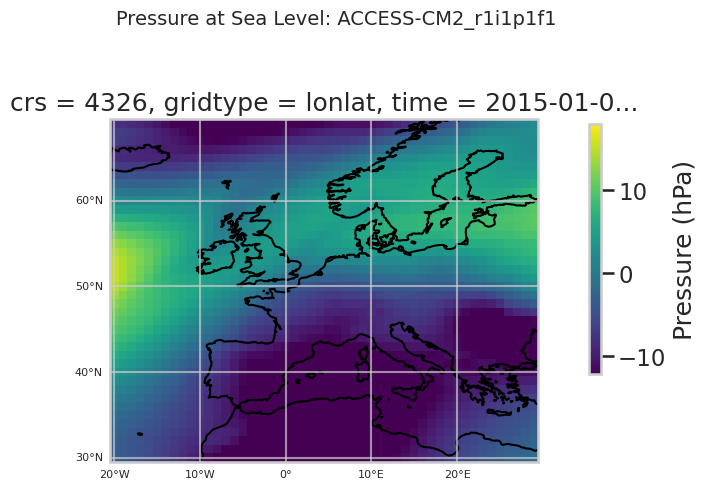

In [83]:
# Select a specific ESM run and one time step
tst = ts_datasets_filtered.sel(time=times[0], ESM_run='CESM2_LE2-1071_004')

# Compute vmin/vmax as Python floats
# vmin_da = tst['psl'].min() / 100
# vmax_da = tst['psl'].max() / 100

# # Force evaluation and extract a scalar
# vmin = float(vmin_da.compute())
# vmax = float(vmax_da.compute())

# Create a figure + Cartopy axis
fig, ax = plt.subplots(
    nrows=1, ncols=1,
    figsize=(6, 5),
    subplot_kw={'projection': ccrs.PlateCarree()}
)

# Shift longitudes from [0, 360] → [–180, +180], sort, convert units, and load
new_lon = ((tst.lon + 180) % 360) - 180
da2 = tst['psl'].assign_coords(lon=new_lon).sortby('lon') / 100
da2 = da2.load()  # now it’s a NumPy array under the hood

# Plot with plain‐float vmin/vmax
p = da2.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap=cmap_used,
    add_colorbar=False,
    vmin=vmin,
    vmax=vmax
)

ax.coastlines()
setup_gridlines(ax, deg=10, alpha=0.7)

# Add colorbar
cbar_ax = fig.add_axes([0.92, 0.25, 0.02, 0.5])
plt.colorbar(p, cax=cbar_ax, label='Pressure (hPa)')

fig.suptitle('Pressure at Sea Level: ACCESS-CM2_r1i1p1f1', fontsize=14)
plt.tight_layout(rect=[0, 0, 0.9, 0.95])
plt.show()


### Select relevant timesteps

In [84]:
# Read the LEE data
LEE_dat = pd.read_csv('/climca/people/onennecke/model_output/LEE_detection/LEE_dat.csv')

LEE_dat_7_all = pd.read_csv('/climca/people/onennecke/model_output/LEE_detection/LEE_dat_7.csv')
LEE_7 = pd.read_csv('/climca/people/onennecke/model_output/LEE_detection/LEE_dat_7_selection.csv')

LEE_dat_14_all = pd.read_csv('/climca/people/onennecke/model_output/LEE_detection/LEE_dat_14.csv')
LEE_14 = pd.read_csv('/climca/people/onennecke/model_output/LEE_detection/LEE_dat_14_selection.csv')

LEE_vl = pd.read_csv('/climca/people/onennecke/model_output/LEE_detection/LEE_vl.csv')

In [85]:
# Remove all SMARD and ERA5_wwd data from the LEE_dat DataFrame
LEE_dat = LEE_dat[(LEE_dat['ESM'] != 'SMARD') & (LEE_dat['ESM'] != 'ERA5_wwd')]
LEE_7 = LEE_7[(LEE_7['ESM'] != 'SMARD') & (LEE_7['ESM'] != 'ERA5_wwd')]
LEE_14 = LEE_14[(LEE_14['ESM'] != 'SMARD') & (LEE_14['ESM'] != 'ERA5_wwd')]
LEE_vl = LEE_vl[(LEE_vl['ESM'] != 'SMARD') & (LEE_vl['ESM'] != 'ERA5_wwd')]

# Rename ESM_run for ERA5_hist_week to ERA5_hist
LEE_dat['ESM_run'] = LEE_dat['ESM_run'].replace({'ERA5_hist_week': 'ERA5_hist'})
LEE_7['ESM_run'] = LEE_7['ESM_run'].replace({'ERA5_hist_week': 'ERA5_hist'})
LEE_14['ESM_run'] = LEE_14['ESM_run'].replace({'ERA5_hist_week': 'ERA5_hist'})
LEE_vl['ESM_run'] = LEE_vl['ESM_run'].replace({'ERA5_hist_week': 'ERA5_hist'})

# Kick every date in April
LEE_dat = LEE_dat[LEE_dat['date_start'].str[5:7] != '04']
LEE_7 = LEE_7[LEE_7['date_start'].str[5:7] != '04']
LEE_14 = LEE_14[LEE_14['date_start'].str[5:7] != '04']
LEE_vl = LEE_vl[LEE_vl['date_start'].str[5:7] != '04']


In [86]:
LEE_dat

,date_start,date_end,date_peak,index_start,index_end,index_peak,duration,RL_max,RL_mean,RL_var,RL_cumulative,event,ESM,ESM_run,year,doy
0,2015-01-05,2015-01-05,2015-01-05,4,4,4,1,1347.755832,1347.755832,0.0,1347.755832,1,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2015,5
1,2015-01-07,2015-01-07,2015-01-07,6,6,6,1,1333.134503,1333.134503,0.0,1333.134503,2,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2015,7
2,2015-01-08,2015-01-08,2015-01-08,7,7,7,1,1395.107358,1395.107358,0.0,1395.107358,3,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2015,8
3,2015-01-18,2015-01-18,2015-01-18,17,17,17,1,1409.547842,1409.547842,0.0,1409.547842,4,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2015,18
4,2015-01-19,2015-01-19,2015-01-19,18,18,18,1,1403.974418,1403.974418,0.0,1403.974418,5,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2015,19
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35218,2024-12-20,2024-12-20,2024-12-20,3638,3638,3638,1,1455.111286,1455.111286,0.0,1455.111286,35219,UKESM1-0-LL,UKESM1-0-LL_r8i1p1f2,2024,354
35219,2024-12-21,2024-12-21,2024-12-21,3639,3639,3639,1,1433.341128,1433.341128,0.0,1433.341128,35220,UKESM1-0-LL,UKESM1-0-LL_r8i1p1f2,2024,355
35220,2024-12-25,2024-12-25,2024-12-25,3643,3643,3643,1,1392.939718,1392.939718,0.0,1392.939718,35221,UKESM1-0-LL,UKESM1-0-LL_r8i1p1f2,2024,359
35221,2024-12-30,2024-12-30,2024-12-30,3648,3648,3648,1,1506.619573,1506.619573,0.0,1506.619573,35222,UKESM1-0-LL,UKESM1-0-LL_r8i1p1f2,2024,364


In [87]:

count = 0
for esm in LEE_7['ESM'].unique():
    esm_entries = LEE_7[LEE_7['ESM'] == esm]
    count += len(esm_entries)
    print(esm, len(esm_entries))
    # if len(esm_entries) > 0:
    #     print(esm_entries['time'].values)
    #     print(esm_entries['cluster'].values)
    #     print('-------------------')
print('Total number of entries:', count)

ACCESS-CM2 31
BCC-CSM2-MR 14
CESM2 1602
EC-Earth3 354
ERA5_week 9
GFDL-ESM4 5
KACE-1-0-G 20
MPI-ESM1-2-HR 139
MRI-ESM2-0 44
TaiESM1 7
UKESM1-0-LL 155
Total number of entries: 2380


In [88]:
# 3) Lookup per‐event cluster
#    assumes `LEE_1_subset` has cols ["date_start","ESM_run"]
LEE_dat["cluster_at_start"] = [
    labels_da.sel(time=dt, ESM_run=run).item()
    for dt, run in zip(LEE_dat.date_start, LEE_dat.ESM_run)
]
LEE_dat

NameError: name 'labels_da' is not defined

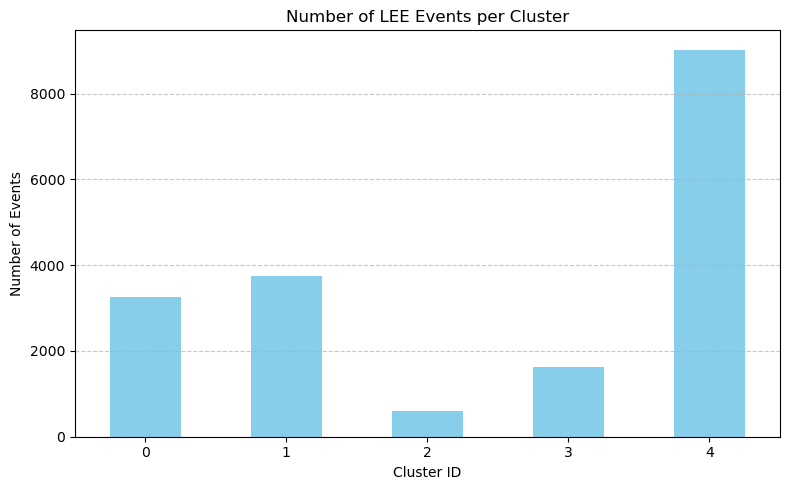

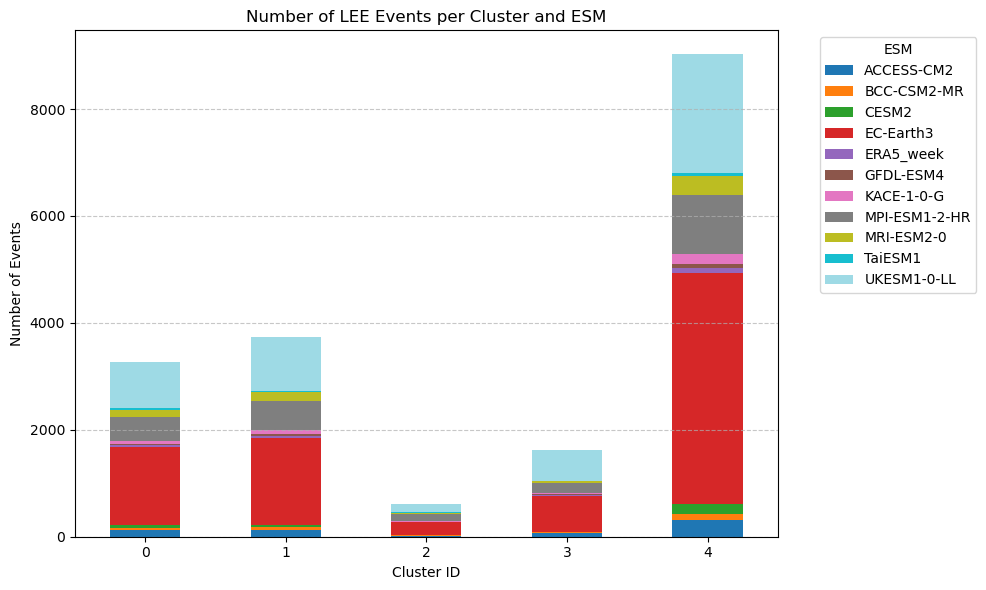

In [46]:
# Make a bar plot of the number of events per cluster
cluster_counts = LEE_dat['cluster_at_start'].value_counts().sort_index()
plt.figure(figsize=(8, 5))
cluster_counts.plot(kind='bar', color='skyblue')
plt.xlabel("Cluster ID")
plt.ylabel("Number of Events")
plt.title("Number of LEE Events per Cluster")
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()
# Make a bar plot of the number of events per cluster and per ESM
cluster_esm_counts = LEE_dat.groupby(['cluster_at_start', 'ESM']).size().unstack(fill_value=0)
plt.figure(figsize=(10, 6))
cluster_esm_counts.plot(kind='bar', stacked=True, colormap='tab20', ax=plt.gca())
plt.xlabel("Cluster ID")
plt.ylabel("Number of Events")
plt.title("Number of LEE Events per Cluster and ESM")
plt.xticks(rotation=0)
plt.legend(title="ESM", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()
# Make a bar plot of the number of events per cluster and per season

In [36]:
# Select one exemplary entry from LEE_1 for each ESM values
def select_exemplary_entries(LEE_df, ESMs):
    exemplary_entries = []
    for esm in ESMs:
        esm_entries = LEE_df[LEE_df['ESM'] == esm]
        if not esm_entries.empty:
            exemplary_entry = esm_entries.iloc[0]  # Select the first entry for each ESM
            exemplary_entries.append(exemplary_entry)
    return pd.DataFrame(exemplary_entries)
# LEE_1_subset = select_exemplary_entries(LEE_1, unique_esms)
# Select one the first run of each ESM from LEE_1
def select_first_run_entries(LEE_df, ESMs):
    first_run_entries = LEE_df.iloc[0:0].copy()

    for esm in ESMs:
        esm_entries = LEE_df[LEE_df['ESM'] == esm]
        if not esm_entries.empty:
            first_run = esm_entries['ESM_run'].unique()[0]
            first_run_entry = esm_entries[esm_entries['ESM_run'] == first_run]
            first_run_entries = pd.concat([first_run_entries, first_run_entry], ignore_index=True)
    return first_run_entries

# LEE_1_subset = select_first_run_entries(LEE_1, unique_esms)
LEE_1_subset = LEE_1.copy()
# LEE_1_subset = LEE_1[0:10]
# LEE_1_subset

In [43]:
LEE_1_subset = LEE_1_subset[~LEE_1_subset['ESM'].isin(['ERA5_wwd', 'ERA5_week'])]
LEE_1_subset['ESM'].unique()

array(['ACCESS-CM2', 'BCC-CSM2-MR', 'CESM2', 'EC-Earth3', 'GFDL-ESM4',
       'KACE-1-0-G', 'MPI-ESM1-2-HR', 'MRI-ESM2-0', 'TaiESM1',
       'UKESM1-0-LL'], dtype=object)

In [44]:
# 3) Lookup per‐event cluster
#    assumes `LEE_1_subset` has cols ["date_start","ESM_run"]
LEE_1_subset["cluster_at_start"] = [
    labels_da.sel(time=dt, ESM_run=run).item()
    for dt, run in zip(LEE_1_subset.date_start, LEE_1_subset.ESM_run)
]
LEE_1_subset

/tmp/ipykernel_4141038/3797269934.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  LEE_1_subset["cluster_at_start"] = [


,date_start,date_end,date_peak,date_start_old,date_end_old,date_peak_old,index_start,index_end,index_peak,duration,RL_max,RL_mean,RL_var,RL_cumulative,ESM,ESM_run,winter,day_of_winter,cluster_at_start
0,2015-01-18 12:00:00,2015-01-18 12:00:00,2015-01-18 12:00:00.000000000,1421582400000000000,1421582400000000000,1421582400000000000,17,17,17,1,1373.585419,1373.585419,0.000000,1373.585419,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2014,110,0
1,2015-10-21 12:00:00,2015-10-21 12:00:00,2015-10-21 12:00:00.000000000,1445428800000000000,1445428800000000000,1445428800000000000,110,110,110,1,1378.601098,1378.601098,0.000000,1378.601098,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2015,21,2
2,2015-11-04 12:00:00,2015-11-05 12:00:00,2015-11-04 12:00:00.000000000,1446638400000000000,1446724800000000000,1446638400000000000,124,125,124,2,1404.935534,1401.253278,3.682256,2802.506556,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2015,35,2
3,2015-12-16 12:00:00,2015-12-17 12:00:00,2015-12-16 12:00:00.000000000,1450267200000000000,1450353600000000000,1450267200000000000,166,167,166,2,1454.631376,1415.495103,39.136273,2830.990205,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2015,77,2
4,2016-12-12 12:00:00,2016-12-12 12:00:00,2016-12-12 12:00:00.000000000,1481544000000000000,1481544000000000000,1481544000000000000,344,344,344,1,1428.634773,1428.634773,0.000000,1428.634773,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2016,73,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5321,2023-12-21 12:00:00,2023-12-21 12:00:00,2023-12-21 12:00:00.000000000,2023-12-22 12:00:00,2023-12-22 12:00:00,2023-12-22 12:00:00,1627,1627,1627,1,1378.105975,1378.105975,0.000000,1378.105975,UKESM1-0-LL,UKESM1-0-LL_r9i1p1f2,2023,82,1
5322,2023-12-23 12:00:00,2023-12-23 12:00:00,2023-12-23 12:00:00.000000000,2023-12-24 12:00:00,2023-12-24 12:00:00,2023-12-24 12:00:00,1629,1629,1629,1,1409.127953,1409.127953,0.000000,1409.127953,UKESM1-0-LL,UKESM1-0-LL_r9i1p1f2,2023,84,1
5323,2024-01-25 12:00:00,2024-01-25 12:00:00,2024-01-25 12:00:00.000000000,2024-01-27 12:00:00,2024-01-27 12:00:00,2024-01-27 12:00:00,1662,1662,1662,1,1390.731921,1390.731921,0.000000,1390.731921,UKESM1-0-LL,UKESM1-0-LL_r9i1p1f2,2023,117,1
5324,2024-11-14 12:00:00,2024-11-14 12:00:00,2024-11-14 12:00:00.000000000,2024-11-15 12:00:00,2024-11-15 12:00:00,2024-11-15 12:00:00,1772,1772,1772,1,1399.713515,1399.713515,0.000000,1399.713515,UKESM1-0-LL,UKESM1-0-LL_r9i1p1f2,2024,45,2


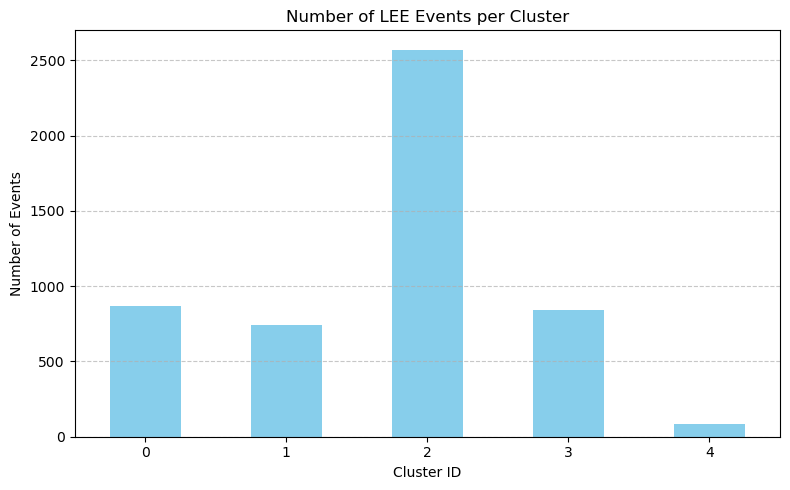

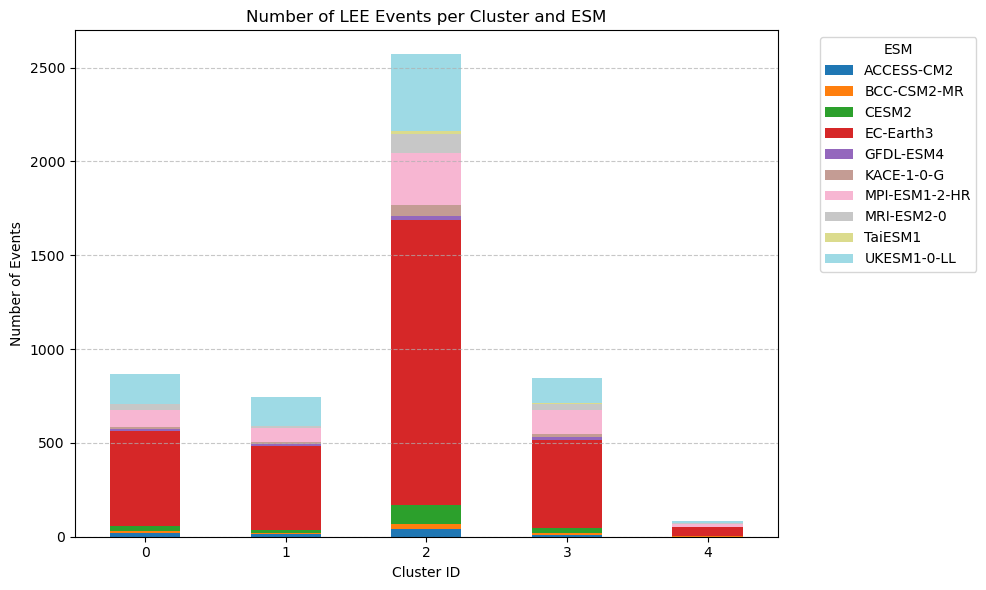

In [45]:
# Make a bar plot of the number of events per cluster
cluster_counts = LEE_1_subset['cluster_at_start'].value_counts().sort_index()
plt.figure(figsize=(8, 5))
cluster_counts.plot(kind='bar', color='skyblue')
plt.xlabel("Cluster ID")
plt.ylabel("Number of Events")
plt.title("Number of LEE Events per Cluster")
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()
# Make a bar plot of the number of events per cluster and per ESM
cluster_esm_counts = LEE_1_subset.groupby(['cluster_at_start', 'ESM']).size().unstack(fill_value=0)
plt.figure(figsize=(10, 6))
cluster_esm_counts.plot(kind='bar', stacked=True, colormap='tab20', ax=plt.gca())
plt.xlabel("Cluster ID")
plt.ylabel("Number of Events")
plt.title("Number of LEE Events per Cluster and ESM")
plt.xticks(rotation=0)
plt.legend(title="ESM", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()
# Make a bar plot of the number of events per cluster and per season

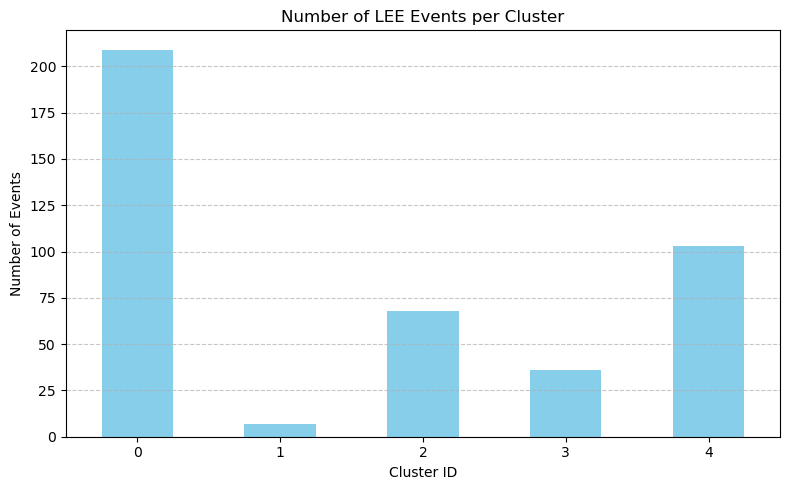

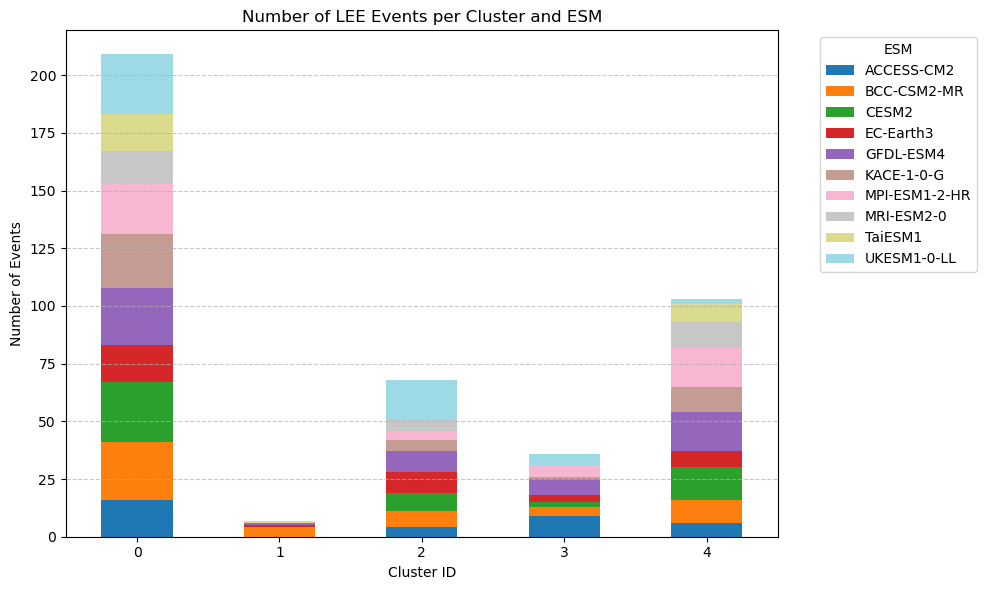

In [142]:
# Make a bar plot of the number of events per cluster
cluster_counts = LEE_1_subset['cluster_at_start'].value_counts().sort_index()
plt.figure(figsize=(8, 5))
cluster_counts.plot(kind='bar', color='skyblue')
plt.xlabel("Cluster ID")
plt.ylabel("Number of Events")
plt.title("Number of LEE Events per Cluster")
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()
# Make a bar plot of the number of events per cluster and per ESM
cluster_esm_counts = LEE_1_subset.groupby(['cluster_at_start', 'ESM']).size().unstack(fill_value=0)
plt.figure(figsize=(10, 6))
cluster_esm_counts.plot(kind='bar', stacked=True, colormap='tab20', ax=plt.gca())
plt.xlabel("Cluster ID")
plt.ylabel("Number of Events")
plt.title("Number of LEE Events per Cluster and ESM")
plt.xticks(rotation=0)
plt.legend(title="ESM", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()
# Make a bar plot of the number of events per cluster and per season

In [ ]:
ts = 9

/tmp/ipykernel_4079217/1653708652.py:42: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 0.95])


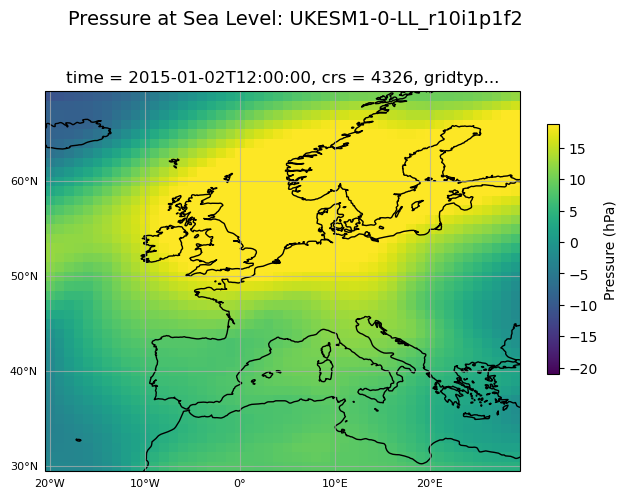

In [ ]:
# Select a specific ESM run and one time step
tst = ts_datasets.sel(ESM_run=LEE_1_subset['ESM_run'].iloc[ts], time=LEE_1_subset['date_start'].iloc[ts])

# Compute vmin/vmax as Python floats
# vmin_da = tst['psl'].min() / 100
# vmax_da = tst['psl'].max() / 100

# # Force evaluation and extract a scalar
# vmin = float(vmin_da.compute())
# vmax = float(vmax_da.compute())

# Create a figure + Cartopy axis
fig, ax = plt.subplots(
    nrows=1, ncols=1,
    figsize=(6, 5),
    subplot_kw={'projection': ccrs.PlateCarree()}
)

# Shift longitudes from [0, 360] → [–180, +180], sort, convert units, and load
new_lon = ((tst.lon + 180) % 360) - 180
da2 = tst['psl'].assign_coords(lon=new_lon).sortby('lon') / 100
da2 = da2.load()  # now it’s a NumPy array under the hood

# Plot with plain‐float vmin/vmax
p = da2.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap=cmap_used,
    add_colorbar=False,
    vmin=vmin,
    vmax=vmax
)

ax.coastlines()
setup_gridlines(ax, deg=10, alpha=0.7)

# Add colorbar
cbar_ax = fig.add_axes([0.92, 0.25, 0.02, 0.5])
plt.colorbar(p, cax=cbar_ax, label='Pressure (hPa)')

fig.suptitle(f'Pressure at Sea Level: {LEE_1_subset['ESM_run'].iloc[ts]}', fontsize=14)
plt.tight_layout(rect=[0, 0, 0.9, 0.95])
plt.show()


----

#### With PCA und scaling
Seems to have lower silhouette scores --> Worse

In [105]:
# 2.1 Scale (standardize) so each “feature” has zero mean & unit variance
scaler = StandardScaler()
X = scaler.fit_transform(arr_flat)
# 2.2 PCA to reduce dimensionality
pca = PCA(n_components=0.90, svd_solver='full')  # keep 90% variance
X_pca = pca.fit_transform(X)  # shape: (n_times, n_eofs)
X_pca
# 3. Run KMeans 
kmeans = KMeans(n_clusters=k, n_init=20, random_state=0)
kmeans.fit(X_pca)  # fit in EOF space
# 4. Extract labels & centroids (in EOF space)
labels = kmeans.labels_            # array length = n_times
centroids_pca = kmeans.cluster_centers_  # shape (4, n_eofs)

# 4.1 Convert centroids back to original space
centroids = pca.inverse_transform(centroids_pca) # back to scaled‐PSL
# 4.2 unscale the centroids
centroids_unscaled = scaler.inverse_transform(centroids) # back to anomaly space

# 5. Reshape centroids to lat/lon grid
centroids_reshaped = centroids_unscaled.reshape(k, n_lat, n_lon)  # shape (4, n_lat, n_lon)

score = silhouette_score(X_pca, labels)
print("Silhouette Score:", score)

Silhouette Score: 0.15489839


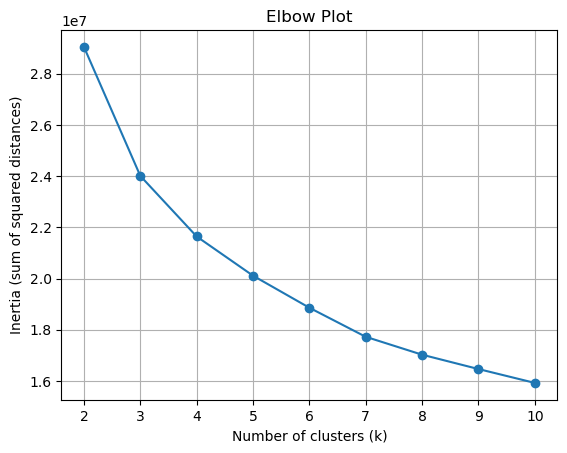

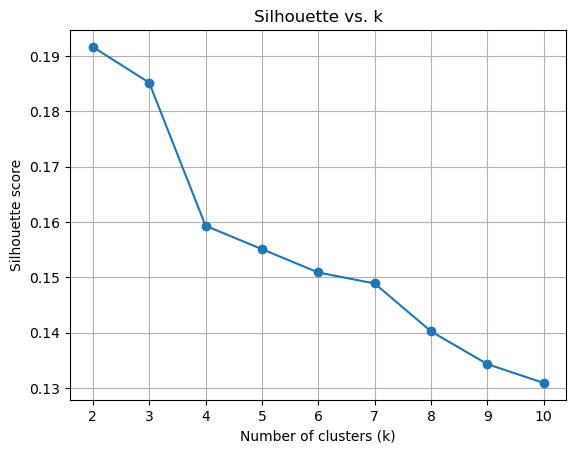

In [ ]:
# ----------------------------------------------------------------------
# 1) Elbow plot + Silhouette‐score vs. k
# ----------------------------------------------------------------------

# Choose which k‐values to test:
k_range = range(2, 11)  # e.g. test k = 2, 3, …, 10

inertias = []
silhouettes = []

for k_test in k_range:
    km = KMeans(n_clusters=k_test, n_init=20, random_state=1)
    labels_k = km.fit_predict(X_pca)      # cluster in EOF‐space
    inertias.append(km.inertia_)          # sum of squared distances to centroids

    # Silhouette: only valid if k_test < n_samples
    silh = silhouette_score(X_pca, labels_k)
    silhouettes.append(silh)

# Plot inertia (elbow)
plt.figure()
plt.plot(list(k_range), inertias, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia (sum of squared distances)")
plt.title("Elbow Plot")
plt.grid(True)
plt.show()

# Plot silhouette score
plt.figure()
plt.plot(list(k_range), silhouettes, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette score")
plt.title("Silhouette vs. k")
plt.grid(True)
plt.show()


In [107]:
# ----------------------------------------------------------------------
# 2) Compute & Plot Composite (Mean) PSL Patterns for each cluster
# ----------------------------------------------------------------------

# Suppose we have chosen k_opt clusters:
k_opt = 5
kmeans = KMeans(n_clusters=k_opt, n_init=20, random_state=0)

# Fit in EOF‐space and get labels
labels = kmeans.fit_predict(X_pca)      # length = n_samples = n_times*n_ESM

# Now, arr_flat has shape (n_samples, n_lat*n_lon).  Each row = one (time, ESM) flattened.
# We want to compute, for i = 0..k_opt-1:
#   mean_flat_i = mean over all samples whose label == i
#   then reshape mean_flat_i → (n_lat, n_lon)

cluster_means = np.zeros((k_opt, n_lat, n_lon))

for i in range(k_opt):
    idx_i = np.where(labels == i)[0]             # all sample‐indices in cluster i
    mean_flat_i = np.mean(arr_flat[idx_i, :], axis=0)  
    cluster_means[i, :, :] = mean_flat_i.reshape(n_lat, n_lon)

# Now cluster_means[i] is the composite PSL field (still in whatever units arr_flat had).
# If arr_flat was “raw PSL,” then these are raw composites.  If arr_flat was “anomalies,”
# add back your climatology if you want absolute values.  But the plotting procedure is the same.


/tmp/ipykernel_88847/1150397827.py:51: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.03, 1, 1])  # leave bottom ~3% of figure for cbar


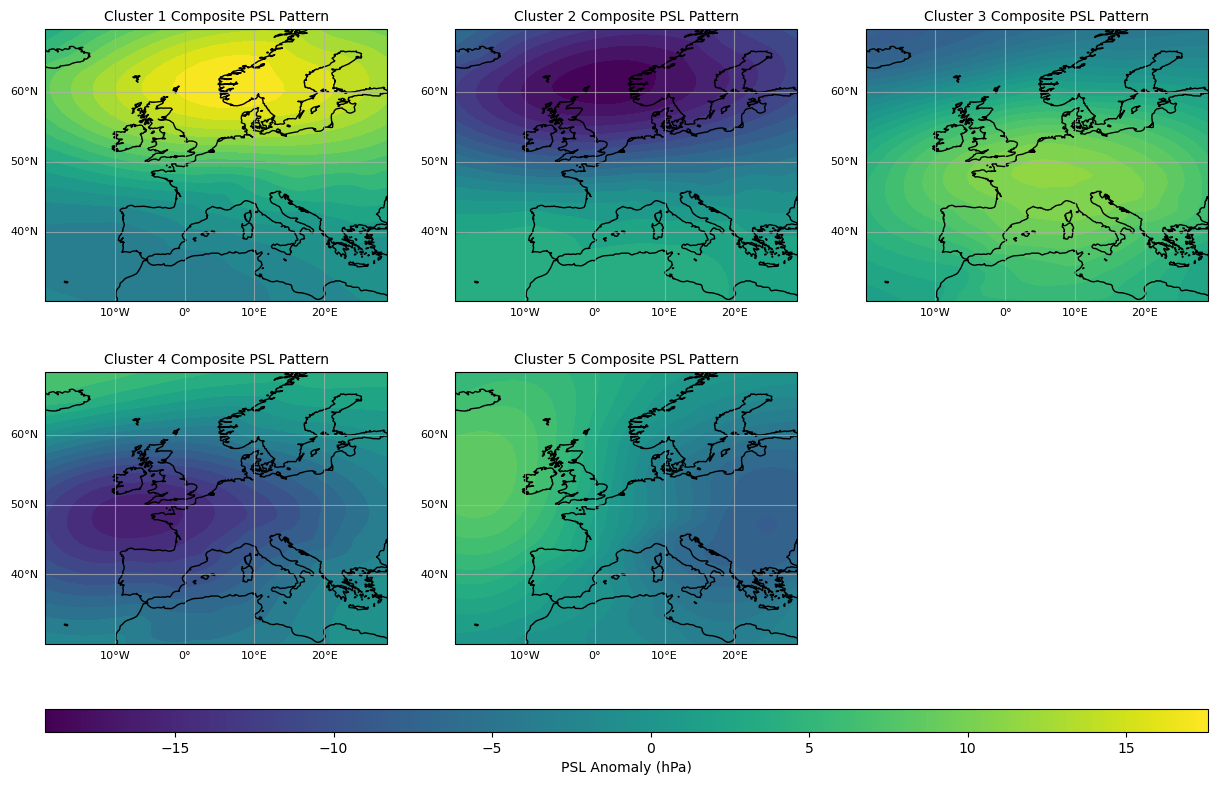

In [ ]:


# 1) Compute the global vmin/vmax over all clusters (in hPa)
vmin = np.nanmin(cluster_means / 100.0)
vmax = np.nanmax(cluster_means / 100.0)

# 2) Decide on subplot grid
ncols = 3
nrows = int(np.ceil(k_opt / ncols))

# 3) Create figure + GridSpec (last row for cbar)
fig = plt.figure(figsize=(5 * ncols, 4 * (nrows + 0.3)))
gs = GridSpec(nrows + 1, ncols,
              height_ratios=[1] * nrows + [0.08],
              hspace=0.3, wspace=0.2)

lons = ((ts_datasets['lon'].values + 180) % 360) - 180
lats = ts_datasets['lat'].values

for i in range(k_opt):
    row = i // ncols
    col = i % ncols
    ax = fig.add_subplot(gs[row, col], projection=ccrs.PlateCarree())

    # Plot with fixed vmin/vmax
    cf = ax.contourf(lons, lats,(cluster_means[i, :, :] / 100.0),levels=20,vmin=vmin,vmax=vmax,transform=ccrs.PlateCarree())
    cmap_used = cf.cmap  # capture the colormap for later

    ax.coastlines()
    setup_gridlines(ax, deg=10, alpha=0.7)
    ax.set_title(f"Cluster {i + 1} Composite PSL Pattern", fontsize=10)

# 5) Hide any “extra” empty axes if k_opt < nrows*ncols
for j in range(k_opt, nrows * ncols):
    row = j // ncols
    col = j % ncols
    fig.add_subplot(gs[row, col]).axis("off")

# 6) Create a ScalarMappable just for the colorbar, using the same colormap/norm
norm = plt.Normalize(vmin=vmin, vmax=vmax)
sm = ScalarMappable(norm=norm, cmap=cmap_used)
sm.set_array([])  # no actual data needed, just for the colorbar

# 7) Place the horizontal colorbar in the final GridSpec row, spanning all columns
cax = fig.add_subplot(gs[nrows, :])
cbar = fig.colorbar(sm, cax=cax, orientation="horizontal", pad=0.02)
cbar.set_label('PSL Anomaly (hPa)' if arr_flat.dtype != 'bool' else '', fontsize=10)

# 8) Tweak layout so maps and cbar don’t overlap
plt.tight_layout(rect=[0, 0.03, 1, 1])  # leave bottom ~3% of figure for cbar
plt.show()


________

#### Without PCA and scaling
Takes quite long and has higher elbow and lower silhouette score --> overall worse

Cluster look the same

In [ ]:
# 2.1 Without standardization
X = arr_flat
# 2.2 Without PCA
# 3. Run KMeans 
kmeans = KMeans(n_clusters=k, n_init=20, random_state=0)
kmeans.fit(X)
# 4. Extract labels & centroids (in EOF space)
labels = kmeans.labels_            # array length = n_times
centroids = kmeans.cluster_centers_  # shape (4, n_eofs)

# 5. Reshape centroids to lat/lon grid
centroids = centroids.reshape(k, n_lat, n_lon)

score = silhouette_score(X, labels)
print("Silhouette Score:", score)


Silhouette Score: 0.16087487


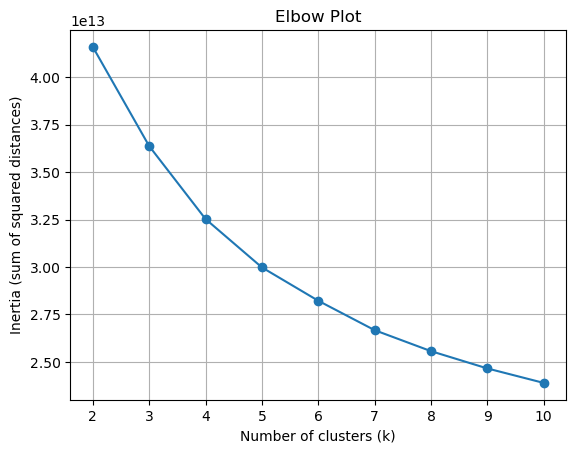

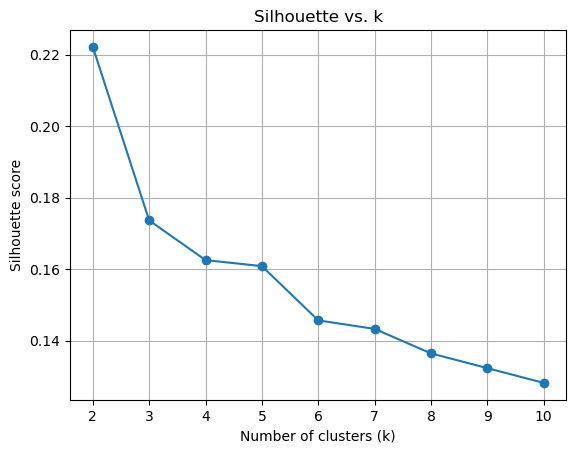

In [ ]:
# ----------------------------------------------------------------------
# 1) Elbow plot + Silhouette‐score vs. k
# ----------------------------------------------------------------------

# Choose which k‐values to test:
k_range = range(2, 11)  # e.g. test k = 2, 3, …, 10

inertias = []
silhouettes = []

for k_test in k_range:
    km = KMeans(n_clusters=k_test, n_init=30, random_state=2)
    labels_k = km.fit_predict(X)      # cluster in EOF‐space
    inertias.append(km.inertia_)          # sum of squared distances to centroids

    # Silhouette: only valid if k_test < n_samples
    silh = silhouette_score(X, labels_k)
    silhouettes.append(silh)

# Plot inertia (elbow)
plt.figure()
plt.plot(list(k_range), inertias, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia (sum of squared distances)")
plt.title("Elbow Plot")
plt.grid(True)
plt.show()

# Plot silhouette score
plt.figure()
plt.plot(list(k_range), silhouettes, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette score")
plt.title("Silhouette vs. k")
plt.grid(True)
plt.show()

In [ ]:
# ----------------------------------------------------------------------
# 2) Compute & Plot Composite (Mean) PSL Patterns for each cluster
# ----------------------------------------------------------------------

# Suppose we have chosen k_opt clusters:
k_opt = 5
kmeans = KMeans(n_clusters=k_opt, n_init=20, random_state=0)

# Fit in EOF‐space and get labels
labels = kmeans.fit_predict(X)      # length = n_samples = n_times*n_ESM

# Now, arr_flat has shape (n_samples, n_lat*n_lon).  Each row = one (time, ESM) flattened.
# We want to compute, for i = 0..k_opt-1:
#   mean_flat_i = mean over all samples whose label == i
#   then reshape mean_flat_i → (n_lat, n_lon)

cluster_means = np.zeros((k_opt, n_lat, n_lon))

for i in range(k_opt):
    idx_i = np.where(labels == i)[0]             # all sample‐indices in cluster i
    mean_flat_i = np.mean(arr_flat[idx_i, :], axis=0)  
    cluster_means[i, :, :] = mean_flat_i.reshape(n_lat, n_lon)

# Now cluster_means[i] is the composite PSL field (still in whatever units arr_flat had).
# If arr_flat was “raw PSL,” then these are raw composites.  If arr_flat was “anomalies,”
# add back your climatology if you want absolute values.  But the plotting procedure is the same.


/tmp/ipykernel_88847/191963972.py:48: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.03, 1, 1])  # leave bottom ~3% of figure for cbar


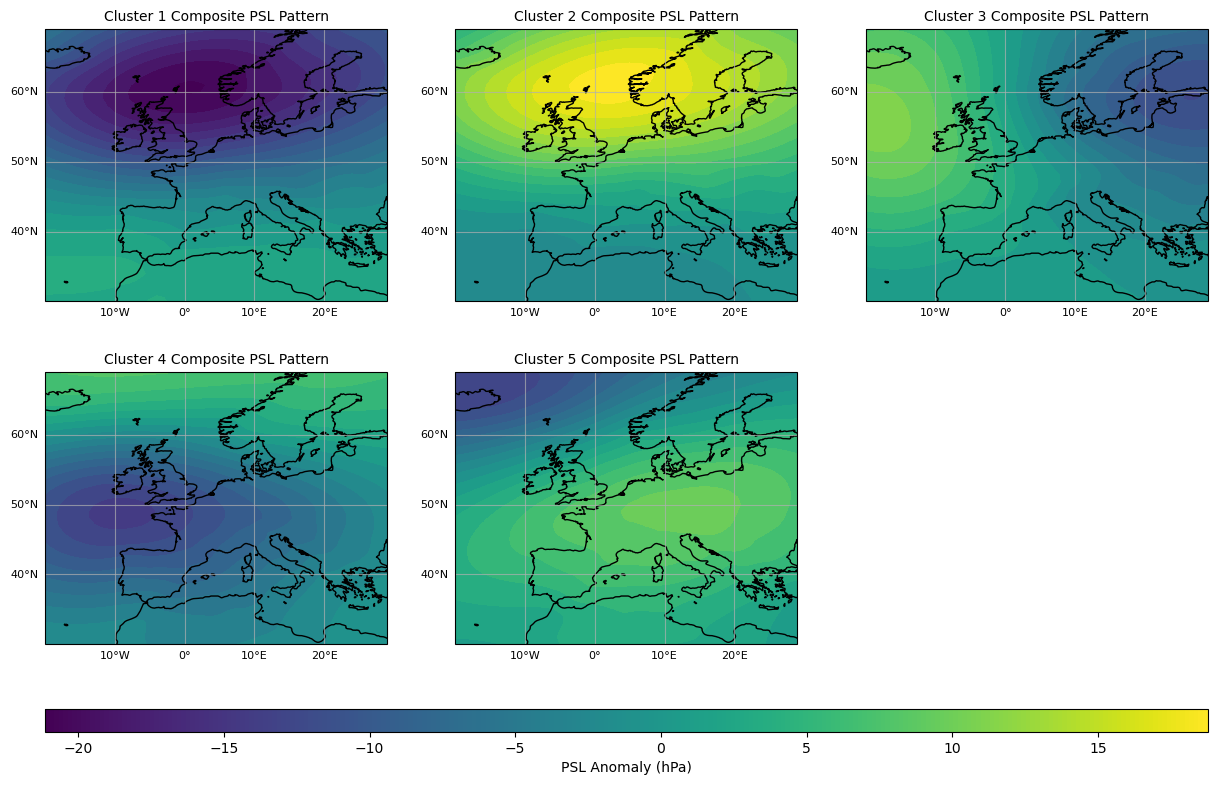

In [ ]:
# 1) Compute the global vmin/vmax over all clusters (in hPa)
vmin = np.nanmin(cluster_means / 100.0)
vmax = np.nanmax(cluster_means / 100.0)

# 2) Decide on subplot grid
ncols = 3
nrows = int(np.ceil(k_opt / ncols))

# 3) Create figure + GridSpec (last row for cbar)
fig = plt.figure(figsize=(5 * ncols, 4 * (nrows + 0.3)))
gs = GridSpec(nrows + 1, ncols,
              height_ratios=[1] * nrows + [0.08],
              hspace=0.3, wspace=0.2)

lons = ((ts_datasets['lon'].values + 180) % 360) - 180
lats = ts_datasets['lat'].values

for i in range(k_opt):
    row = i // ncols
    col = i % ncols
    ax = fig.add_subplot(gs[row, col], projection=ccrs.PlateCarree())

    # Plot with fixed vmin/vmax
    cf = ax.contourf(lons, lats,(cluster_means[i, :, :] / 100.0),levels=20,vmin=vmin,vmax=vmax,transform=ccrs.PlateCarree())
    cmap_used = cf.cmap  # capture the colormap for later

    ax.coastlines()
    setup_gridlines(ax, deg=10, alpha=0.7)
    ax.set_title(f"Cluster {i + 1} Composite PSL Pattern", fontsize=10)

# 5) Hide any “extra” empty axes if k_opt < nrows*ncols
for j in range(k_opt, nrows * ncols):
    row = j // ncols
    col = j % ncols
    fig.add_subplot(gs[row, col]).axis("off")

# 6) Create a ScalarMappable just for the colorbar, using the same colormap/norm
norm = plt.Normalize(vmin=vmin, vmax=vmax)
sm = ScalarMappable(norm=norm, cmap=cmap_used)
sm.set_array([])  # no actual data needed, just for the colorbar

# 7) Place the horizontal colorbar in the final GridSpec row, spanning all columns
cax = fig.add_subplot(gs[nrows, :])
cbar = fig.colorbar(sm, cax=cax, orientation="horizontal", pad=0.02)
cbar.set_label('PSL Anomaly (hPa)' if arr_flat.dtype != 'bool' else '', fontsize=10)

# 8) Tweak layout so maps and cbar don’t overlap
plt.tight_layout(rect=[0, 0.03, 1, 1])  # leave bottom ~3% of figure for cbar
plt.show()
